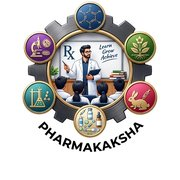

# BP101T · Unit II — Control Structures and Functions
**Pharmakaksha · Learn · Grow · Achieve**
*Basics of Python Programming for Pharmaceutical Sciences · B.Pharm Semester I · PCI NEP 2020*

This notebook contains every example and demo from the Unit II study notes, slides and video, in the same order.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ajreddys/learn-pharmakaksha-site/blob/main/content/BP101T%20Basics%20of%20Python%20Programming%20for%20Pharmaceutical%20Sciences%20%28Theory%29/BP101T_Unit2_Control_Structures_and_Functions.ipynb)

**How to use this notebook**
1. Open it at [learn.pharmakaksha.com](https://learn.pharmakaksha.com/notebooks/index.html?path=BP101T%20Basics%20of%20Python%20Programming%20for%20Pharmaceutical%20Sciences%20%28Theory%29/BP101T_Unit2_Control_Structures_and_Functions.ipynb) (no login needed) or in **Google Colab** with the button above (sign in with Google; use **File → Save a copy in Drive** to keep your work).
2. Click a code cell and press **Shift + Enter** to run it. Run the cells from top to bottom.
3. Cells marked ⌨️ ask you to type something. Type your answer in the box that appears and press Enter.

**Using learn.pharmakaksha.com**
Python runs inside your web browser, so nothing is installed and nothing is sent to a server. Use an up-to-date Chrome, Edge, Firefox or Safari, on a laptop or a phone.
- **The first run is slow.** The first time you run a cell, the browser downloads Python, which can take 10–30 seconds. After that, cells run quickly.
- **Check the kernel.** *Python (Pyodide)* appears at the top right. A filled circle means Python is busy, and an empty circle means it is ready.
- **If a cell hangs** or you want a fresh start, use **Kernel → Restart Kernel**, then run the cells from the top again.
- **Save your work.** Press **Ctrl + S** (**Cmd + S** on a Mac). Your work is saved in this browser only. It will not appear on another device, and clearing your browsing data or using a private/incognito window erases it. Use **File → Download** to keep a copy.
- **Start over.** The site keeps opening your saved copy of the notebook. To get the original version back, go to the file list, tick the notebook, click **Delete** and reload the page.

> All dosing and study data in this notebook are for learning Python only. They are not clinical tools.

## 2.1 Conditional statements
A condition is `True` or `False`. The condition line ends with a colon `:`, and the code that belongs to it is **indented by 4 spaces**.

**if** runs the block only when the condition is True.

In [ ]:
temp = 38.6
if temp >= 38.0:
    print("Fever: consider an antipyretic")

**if-else** chooses between two paths. Change `crcl` to 80 and run it again.

In [ ]:
crcl = 45                      # creatinine clearance, mL/min
if crcl < 50:
    print("Reduce the dose")
else:
    print("Normal dose")

**if-elif-else** chooses one of many paths. Python checks the conditions from the top and runs **only the first** one that is True. Try BMI values of 17, 22 and 31.

In [ ]:
bmi = 27.4
if bmi < 18.5:
    category = "Underweight"
elif bmi < 25:
    category = "Normal"
elif bmi < 30:
    category = "Overweight"
else:
    category = "Obese"
print(category)

**Nested conditions:** an if inside another if, for decisions that depend on two factors.

In [ ]:
age, crcl = 70, 40
if age >= 65:
    if crcl < 50:
        print("Elderly with renal impairment: reduce dose and monitor")
    else:
        print("Elderly: monitor")
else:
    print("Adult dose")

The nested version can often be flattened with `and`:

In [ ]:
age, crcl = 70, 40
if age >= 65 and crcl < 50:
    print("Elderly with renal impairment: reduce dose and monitor")

**Common errors.** Remove the `#` from **one** line at a time and run the cell to see each error, then put the `#` back.
- A missing colon gives a **SyntaxError**.
- A missing indent gives an **IndentationError**.

In [ ]:
temp = 38.6
# if temp >= 38.0                        # SyntaxError: missing colon
#     print("Fever")
# if temp >= 38.0:
# print("Fever")                         # IndentationError: not indented
if temp >= 38.0:
    print("Fever")                       # correct

## 2.2 Loops
A **for loop** repeats once for each item in a sequence.

In [ ]:
for drug in ["Paracetamol", "Ibuprofen", "Aspirin"]:
    print(drug.upper())

**range(start, stop, step)** generates numbers from start up to, **but not including**, stop. `list()` shows them all at once.

In [ ]:
print(list(range(5)))
print(list(range(1, 5)))
print(list(range(0, 25, 6)))      # a q6h dosing schedule

A drug at 100 mg/L halves every half-life:

In [ ]:
c = 100.0                       # initial concentration, mg/L
for t in range(1, 5):
    c = c * 0.5                 # halves every half-life
    print(f"After {t} half-life(s): {c} mg/L")

A **while loop** repeats **as long as** a condition stays True. How long until the level falls below 12.5 mg/L (t½ = 4 h)?

In [ ]:
c = 100.0
hours = 0
while c >= 12.5:                # t½ = 4 h
    c = c / 2
    hours = hours + 4
print(f"Below 12.5 mg/L after {hours} h ({c} mg/L)")

> **Pharma link:** about 4–5 half-lives are needed to eliminate most of a drug.
>
> **Warning:** if nothing inside a while loop changes the condition, it runs forever (an infinite loop). Stop it with the ■ button, or **Kernel → Interrupt Kernel**.

## 2.3 break and continue
**break** exits the loop immediately. Here it stops checking once a batch fails the assay limit (95–105%).

In [ ]:
assays = [99.2, 98.7, 94.1, 100.3]
batch_no = 0
for assay in assays:
    batch_no = batch_no + 1
    if assay < 95 or assay > 105:
        print(f"Batch {batch_no} FAILED ({assay}%). Stop release check.")
        break
    print(f"Batch {batch_no} OK")

Batch 4 is never checked, because `break` ended the loop.

**continue** skips the rest of the current repeat. Here it skips out-of-stock drugs.

In [ ]:
drugs = ["Paracetamol", "Amoxicillin", "Metformin"]
stock = [120, 0, 45]
for i in range(len(drugs)):
    if stock[i] == 0:
        continue                # skip this one
    print(drugs[i], "in stock:", stock[i])

**pass** does nothing. It is a placeholder where Python needs a block:

In [ ]:
for drug in drugs:
    pass                        # to do: write this later
print("Loop finished")

## 2.4 Functions
A **function** is a named, reusable block of code. Define it with `def`, then call it by name.

In [ ]:
def greet():                    # definition: def, name, (), colon
    print("Welcome to Pharmakaksha")

greet()                         # call: runs the body

**Parameters, arguments and return.** `k` is the parameter; `0.173` is the argument.

In [ ]:
def half_life(k):               # k is a parameter
    return 0.693 / k            # sends a value back

t_half = half_life(0.173)       # 0.173 is the argument
print(round(t_half, 2))

**Ways of passing arguments:** positional, keyword, and using a default value.

In [ ]:
def dose_by_weight(weight_kg, mg_per_kg=15):   # 15 is a default value
    return weight_kg * mg_per_kg

print(dose_by_weight(20, 10))                    # positional       -> 200
print(dose_by_weight(mg_per_kg=10, weight_kg=20))  # keyword        -> 200
print(dose_by_weight(20))                        # uses the default -> 300

**Returning more than one value:**

In [ ]:
def concentrations(dose_mg, vd_l):
    c0 = dose_mg / vd_l
    return c0, c0 / 2           # returns two values

c0, c_after_one_half_life = concentrations(500, 40)
print(c0, c_after_one_half_life)

**print() vs return.** A function that only prints gives back `None`, so its result can't be reused.

In [ ]:
def show_dose(w):
    print(w * 15)               # shows the value

def get_dose(w):
    return w * 15               # hands the value back

a = show_dose(20)               # prints 300 ...
b = get_dose(20)
print(a, b)                     # ... but a is None; b is 300

**Scope.** Variables created inside a function are **local**. Remove the `#` to see the NameError, then put it back.

In [ ]:
def calc():
    result = 42                 # local variable
    return result

print(calc())
# print(result)                 # NameError: result exists only inside calc()

## 2.5 Modular programs: BMI and dosage calculation
A **modular program** is built from small functions, each doing one job. The main part only calls them.

### Program 1: BMI calculator
BMI = weight (kg) ÷ height (m)², with the WHO categories.

In [ ]:
def calculate_bmi(weight_kg, height_cm):
    height_m = height_cm / 100
    return weight_kg / height_m ** 2

def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

⌨️ **Try it:** run the main program and type a weight and a height, for example `52` and `160`.

In [ ]:
# main program
weight = float(input("Weight (kg): "))
height = float(input("Height (cm): "))
bmi = calculate_bmi(weight, height)
print(f"BMI = {bmi:.1f} ({bmi_category(bmi)})")

The three test cases from the notes, checked in a loop:

In [ ]:
for weight, height in [(52, 160), (82, 172), (98, 168)]:
    bmi = calculate_bmi(weight, height)
    print(f"{weight} kg, {height} cm -> BMI = {bmi:.1f} ({bmi_category(bmi)})")

### Program 2: dosage calculator
**Young's rule** (by age): child dose = adult dose × age ÷ (age + 12).
**Clark's rule** (by weight): child dose = adult dose × weight (kg) ÷ 70.

In [ ]:
def weight_based_dose(weight_kg, mg_per_kg, max_dose_mg):
    dose = weight_kg * mg_per_kg
    if dose > max_dose_mg:
        dose = max_dose_mg          # never exceed the maximum
    return dose

def youngs_dose(adult_dose_mg, age_years):
    return adult_dose_mg * age_years / (age_years + 12)

def clarks_dose(adult_dose_mg, weight_kg):
    return adult_dose_mg * weight_kg / 70

def print_schedule(interval_h, start_h=8):
    for t in range(start_h, start_h + 24, interval_h):
        print(f"{t % 24:02d}:00", end="  ")
    print()

# main program
print(weight_based_dose(18, 15, 1000))      # 270
print(weight_based_dose(80, 15, 1000))      # 1000 (capped)
print(round(youngs_dose(500, 6), 1))        # 166.7 mg for a 6-year-old
print(round(clarks_dose(500, 21), 1))       # 150.0 mg for a 21 kg child
print_schedule(6)                           # 08:00  14:00  20:00  02:00

**Check by hand:** 500 × 6 ÷ 18 = 166.7 mg and 500 × 21 ÷ 70 = 150 mg. `% 24` wraps 26:00 round to 02:00.

> These are teaching examples. Real paediatric doses come from approved references such as the IAP guidelines or BNFc.

## Quick check
What does this loop print? Decide first, then run the cell.

In [ ]:
for i in range(5):
    if i == 3:
        break
    print(i)

## Try it yourself (lab)
Write your code in the empty cells. Solutions are at the end of the notebook.

**1.** Classify creatinine clearance: ≥ 90 normal, 60–89 mild, 30–59 moderate, 15–29 severe, and < 15 kidney failure.

In [ ]:
# your code here

**2.** Print a q8h schedule starting at 06:00 using `range()`.

In [ ]:
# your code here

**3.** Write `bsa(height_cm, weight_kg)` using the Mosteller formula, √(height × weight ÷ 3600). Use it to scale an adult dose: child dose = adult dose × BSA ÷ 1.73.

In [ ]:
# your code here

**4.** Loop over a list of tablet weights and stop (with `break`) at the first tablet outside ±5% of 500 mg.

In [ ]:
# your code here

---
## Solutions

In [ ]:
# 1
def crcl_stage(crcl):
    if crcl >= 90:
        return "Normal"
    elif crcl >= 60:
        return "Mild"
    elif crcl >= 30:
        return "Moderate"
    elif crcl >= 15:
        return "Severe"
    else:
        return "Kidney failure"

for value in [95, 72, 45, 20, 10]:
    print(value, crcl_stage(value))

In [ ]:
# 2
for t in range(6, 6 + 24, 8):
    print(f"{t % 24:02d}:00", end="  ")
print()

In [ ]:
# 3
import math

def bsa(height_cm, weight_kg):
    return math.sqrt(height_cm * weight_kg / 3600)

child_bsa = bsa(120, 22)
print(f"BSA = {child_bsa:.2f} m²")
print(f"Child dose = {500 * child_bsa / 1.73:.0f} mg (adult dose 500 mg)")

In [ ]:
# 4
weights = [498.2, 503.1, 512.7, 470.4, 501.0]
for w in weights:
    if w < 475 or w > 525:
        print("First tablet outside ±5%:", w)
        break
    print(w, "OK")

---
**Next:** Unit III — Data Structures and File Handling. Pharmakaksha · Learn · Grow · Achieve